# **Prédiction de la gravité des accidents de la route par machine learning**

# Introduction

Ce notebook a pour objectif d’étudier et de modéliser la gravité des accidents de la route à partir des données nationales disponibles entre 2014 et 2020 (sauf 2019). Nous cherchons à prédire si un accident est grave ou non en utilisant différentes informations décrivant les conditions de l’accident, les caractéristiques des usagers impliqués et le contexte environnemental.

Après avoir préparé et harmonisé les données, plusieurs modèles de machine learning sont entraînés et comparés. Une première évaluation simple permet d’obtenir un aperçu de leurs performances, avant d’utiliser une validation chronologique afin de respecter la dimension temporelle des données et d’assurer la robustesse des résultats.

Les modèles les plus performants sont ensuite optimisés à l’aide d’Optuna, ce qui permet d’améliorer leurs hyperparamètres de manière systématique et efficace. Enfin, une analyse de l’importance des variables est réalisée pour mieux comprendre le comportement des modèles et identifier les facteurs qui contribuent le plus à la prédiction de la gravité.

Ce notebook présente l’ensemble de ces étapes, depuis la préparation des données jusqu’à l’interprétation finale des modèles.

# Préparation des données


In [26]:
# -----------------------------
# Import des librairies
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

import warnings
warnings.filterwarnings("ignore")


# -----------------------------
# Fonctions utilitaires
# -----------------------------
def charger_preparer_donnees(annee):
    df = pd.read_csv(
        f"{annee}.csv",
        sep=";",
        na_values=["", " ", "NULL"]
    )

    int_cols = ["hrmn", "mois", "an_nais", "grav"]
    str_cols = ["lum", "col","catu", "sexe","dep", "plan", "obs", "catv"]

    df[int_cols] = df[int_cols].astype("Int64")
    df[str_cols] = df[str_cols].astype("string")
    df["Num_Acc"] = df["Num_Acc"].astype("int64")

    # Corriger les départements
    corse_mapping_old = {"201": "2A", "202": "2B"}

    if annee in [2014, 2015, 2016, 2017, 2018]:
        df["dep"] = df["dep"].astype(str)
        # Appliquer le mapping Corse
        df["dep"] = df["dep"].replace(corse_mapping_old)
        # Enlever le dernier 0 pour les autres départements
        df.loc[~df["dep"].isin(corse_mapping_old.values()), "dep"] = df.loc[~df["dep"].isin(corse_mapping_old.values()), "dep"].str[:-1]

    df["gravite"] = df["grav"].apply(lambda x: 1 if x in [2, 3] else 0)

    X = df.drop(columns=["Num_Acc", "grav", "gravite", "num_veh"])
    y = df["gravite"]

    X = pd.get_dummies(X, drop_first=True)

    return X, y


def entr_eval_modele(pipeline, X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print("Accuracy (test) :", accuracy_score(y_test, y_pred))

    print("\nConfusion Matrix :")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report :")
    print(classification_report(y_test, y_pred))

    scores = cross_val_score(pipeline, X_train, y_train, cv=5)

    print("\nValidation croisée (train) :", scores)
    print("Score moyen :", scores.mean())

    return scores.mean()  # important



def validation_chronologique(pipeline, data, annees):
    annees_sorted = sorted(annees)
    scores = []

    print("\n============================")
    print("Validation croisée chronologique")
    print("============================")

    for i in range(1, len(annees_sorted)):
        # Train = toutes les années jusqu'à i-1
        annees_train = annees_sorted[:i]
        # Test = année i
        annee_test = annees_sorted[i]

        # Concaténer les années d'entraînement
        X_train = pd.concat([data[a][0] for a in annees_train], axis=0)
        y_train = pd.concat([data[a][1] for a in annees_train], axis=0)

        # Données de test
        X_test, y_test = data[annee_test]

        # Entraînement
        pipeline.fit(X_train, y_train)

        # Prédiction
        y_pred = pipeline.predict(X_test)
        score = accuracy_score(y_test, y_pred)
        scores.append(score)

        print(f"Train = {annees_train} → Test = {annee_test} | Score = {score:.4f}")

    print("\nScore moyen (chronologique) :", np.mean(scores))
    print("Écart-type :", np.std(scores))

    return np.mean(scores)


# -----------------------------
# Chargement des données (une seule fois)
# -----------------------------
annees = [2014, 2015, 2016, 2017, 2018, 2020]


# Première passe : collecter toutes les colonnes possibles
colonnes_globales = set()

for annee in annees:
    X, y = charger_preparer_donnees(annee)
    colonnes_globales.update(X.columns)

# Deuxième passe : recharger les données en alignant les colonnes
data = {}

for annee in annees:
    X, y = charger_preparer_donnees(annee)
    # réaligner les colonnes manquantes
    X = X.reindex(columns=sorted(colonnes_globales), fill_value=0)
    data[annee] = (X, y)



<br>

# 1. Evaluation des modèles

## Modèle 1 - Logistic Regression

### Principe

La régression logistique est un modèle linéaire utilisé pour la classification binaire.  
Elle permet ici de prédire la probabilité qu’un accident soit grave en fonction des variables explicatives.

Ce modèle servira de référence pour comparer les performances avec des modèles plus complexes.

In [ ]:
# Pipeline
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

print("\n============================")
print("Modèle : Logistic Regression")
print("============================")

cv_means = []

for annee in annees:
    print(f"\n--- Année {annee} ---")

    X, y = data[annee]
    mean_score = entr_eval_modele(pipeline, X, y)

    cv_means.append(mean_score)

print("\n============================")
print("MOYENNE CV SUR TOUTES LES ANNÉES")
print("============================")

print("Score moyen global :", np.mean(cv_means))
print("Écart-type :", np.std(cv_means))


Modèle : Logistic Regression

--- Année 2014 ---
Accuracy (test) : 0.7991905590438005

Confusion Matrix :
[[18877  1242]
 [ 4067  2252]]

Classification Report :
              precision    recall  f1-score   support

           0       0.82      0.94      0.88     20119
           1       0.64      0.36      0.46      6319

    accuracy                           0.80     26438
   macro avg       0.73      0.65      0.67     26438
weighted avg       0.78      0.80      0.78     26438


Validation croisée (train) : [0.79791962 0.80297872 0.80335697 0.80174003 0.80008511]
Score moyen : 0.8012160929091763

--- Année 2015 ---
Accuracy (test) : 0.7954824359564351

Confusion Matrix :
[[18393  1416]
 [ 3917  2350]]

Classification Report :
              precision    recall  f1-score   support

           0       0.82      0.93      0.87     19809
           1       0.62      0.37      0.47      6267

    accuracy                           0.80     26076
   macro avg       0.72      0.65      

In [ ]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

validation_chronologique(pipeline, data, annees)


Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7957
Train = [2014, 2015] → Test = 2016 | Score = 0.7711
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7947
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8180
Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8196

Score moyen (chronologique) : 0.7997974614518013
Écart-type : 0.017819610090239798


np.float64(0.7997974614518013)

### **Interprétation des résultats**

#### 1. <u>Evaluation année par année</u>

La régression logistique montre une **stabilité remarquable** d’une année à l’autre, avec une accuracy généralement comprise entre **0.79 et 0.84**.  
Le modèle parvient très bien à prédire les accidents **non graves** (classe majoritaire), mais il présente une **faible sensibilité pour les accidents graves**, avec un rappel systématiquement bas pour la classe 1.

En pratique :
- Le modèle est **robuste et cohérent** dans le temps.
- Il est **fortement biaisé vers la classe majoritaire**, ce qui limite sa capacité à identifier les accidents graves.
- Les scores de validation croisée annuels confirment cette stabilité (écart-type faible).

**Conclusion (année par année)** :  
La régression logistique est fiable mais insuffisante pour détecter correctement les accidents graves, ce qui est une limite importante dans un contexte de sécurité routière.

---

#### 2. <u>Evaluation par validation croisée chronologique</u>
La validation croisée chronologique confirme les observations précédentes :
- Le score moyen est d’environ **0.80**, très proche des performances annuelles.
- Les variations d’une période à l’autre restent faibles (écart-type ≈ 0.018), signe d’un modèle **stable et non surappris**.
- Les performances augmentent légèrement lorsque davantage d’années sont utilisées pour l’entraînement, ce qui montre que le modèle **bénéficie de plus de données**, mais sans résoudre le problème du rappel faible sur la classe 1.

**Conclusion chrono** :  
Le modèle généralise correctement dans le temps, mais ses limites structurelles (linéarité, déséquilibre des classes) persistent.

---

### Conclusion globale pour Logistic Regression
La régression logistique constitue une **baseline solide**, stable et interprétable.  
Cependant, elle **échoue à capturer la complexité des accidents graves**, ce qui se traduit par un rappel faible et un f1-score limité pour la classe 1.  


## Modèle 2 - Decision Tree

### Principe

L’arbre de décision est un modèle non linéaire qui segmente les données en fonction de règles de décision successives.

Il permet de capturer des relations plus complexes entre les variables que les modèles linéaires comme la régression logistique.  
Cependant, il peut être sensible au surapprentissage (overfitting) si sa profondeur n’est pas contrôlée.

In [ ]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", DecisionTreeClassifier(random_state=42))
])

print("\n============================")
print("Modèle : Decision Tree")
print("============================")

cv_means = []

for annee in annees:
    print(f"\n--- Année {annee} ---")

    X, y = data[annee]

    mean_score = entr_eval_modele(pipeline, X, y)  # récupère

    cv_means.append(mean_score)  # stocke

print("\n============================")
print("MOYENNE CV SUR TOUTES LES ANNÉES")
print("============================")

print("Score moyen global :", np.mean(cv_means))
print("Écart-type :", np.std(cv_means))


Modèle : Decision Tree

--- Année 2014 ---
Accuracy (test) : 0.7511914668280505

Confusion Matrix :
[[16933  3186]
 [ 3392  2927]]

Classification Report :
              precision    recall  f1-score   support

           0       0.83      0.84      0.84     20119
           1       0.48      0.46      0.47      6319

    accuracy                           0.75     26438
   macro avg       0.66      0.65      0.65     26438
weighted avg       0.75      0.75      0.75     26438


Validation croisée (train) : [0.74619385 0.74959811 0.75413712 0.74585087 0.74816776]
Score moyen : 0.748789541547326

--- Année 2015 ---
Accuracy (test) : 0.7402975916551618

Confusion Matrix :
[[16372  3437]
 [ 3335  2932]]

Classification Report :
              precision    recall  f1-score   support

           0       0.83      0.83      0.83     19809
           1       0.46      0.47      0.46      6267

    accuracy                           0.74     26076
   macro avg       0.65      0.65      0.65   

In [ ]:
# Pipeline
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", DecisionTreeClassifier(random_state=42))
])

validation_chronologique(pipeline, data, annees)


Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7314
Train = [2014, 2015] → Test = 2016 | Score = 0.6905
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7283
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.7439
Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.7343

Score moyen (chronologique) : 0.7256816788616878
Écart-type : 0.018361154018403943


np.float64(0.7256816788616878)

### **Interprétation des résultats**

#### 1. <u>Évaluation année par année</u>

Le Decision Tree présente des performances globalement **inférieures à celles de la régression logistique**, avec une accuracy généralement située entre **0.74 et 0.79** selon les années.  
Le modèle parvient à capturer davantage de non‑linéarités que la régression logistique, mais il reste **instable** et plus sensible au bruit des données.

Les tendances générales observées :
- Le modèle prédit correctement la classe majoritaire (accidents non graves), mais la **classe 1 reste difficile à détecter**, avec un rappel autour de **0.42–0.48**.
- Les performances varient davantage d’une année à l’autre, ce qui reflète la **sensibilité des arbres de décision au surapprentissage**.
- Les scores de validation croisée annuels (≈0.74–0.78) confirment cette variabilité, avec un écart‑type plus élevé que pour la régression logistique.

**Conclusion (année par année)** :  
Le Decision Tree capture mieux certaines structures non linéaires mais reste **moins stable** et **moins performant globalement**. Il souffre d’un **surapprentissage récurrent** et peine à identifier correctement les accidents graves.

---

#### 2. <u>Évaluation par validation croisée chronologique</u>

La validation croisée chronologique confirme les limites du modèle :
- Le score moyen est d’environ **0.726**, nettement inférieur à celui de la régression logistique.
- Les performances fluctuent davantage d’une période à l’autre (écart‑type ≈ 0.018), signe d’un modèle **moins robuste dans le temps**.
- L’ajout d’années supplémentaires n’améliore pas significativement la performance, ce qui montre que le modèle **ne généralise pas bien** sur des données futures.

**Conclusion chrono** :  
Le Decision Tree manque de stabilité temporelle et généralise moins bien que les modèles linéaires. Ses performances restent limitées, notamment sur la classe minoritaire.

---

### Conclusion globale pour Decision Tree
Le Decision Tree offre une première approche non linéaire, mais ses performances restent **modestes**, avec une forte variabilité et un risque d’overfitting.  
Il détecte mal les accidents graves et se révèle **moins fiable** que la régression logistique, tant en évaluation annuelle qu’en validation chronologique.

## Modèle 3 - Random Forest

### Principe

La forêt aléatoire (Random Forest) est un modèle d’ensemble basé sur une collection d’arbres de décision.

Chaque arbre est entraîné sur un sous-échantillon des données, et la prédiction finale est obtenue par agrégation des résultats de tous les arbres.

Cette approche permet de réduire l’instabilité des arbres de décision et d’améliorer les performances globales du modèle.

In [ ]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestClassifier(
        n_estimators=50,
        n_jobs=-1,
        random_state=42
    ))
])

print("\n============================")
print("Modèle : Random Forest")
print("============================")

cv_means = []

for annee in annees:
    print(f"\n--- Année {annee} ---")

    X, y = data[annee]

    mean_score = entr_eval_modele(pipeline, X, y)  # récupère

    cv_means.append(mean_score)  # stocke

print("\n============================")
print("MOYENNE CV SUR TOUTES LES ANNÉES")
print("============================")

print("Score moyen global :", np.mean(cv_means))
print("Écart-type :", np.std(cv_means))


Modèle : Random Forest

--- Année 2014 ---
Accuracy (test) : 0.8043724941372267

Confusion Matrix :
[[18731  1388]
 [ 3784  2535]]

Classification Report :
              precision    recall  f1-score   support

           0       0.83      0.93      0.88     20119
           1       0.65      0.40      0.50      6319

    accuracy                           0.80     26438
   macro avg       0.74      0.67      0.69     26438
weighted avg       0.79      0.80      0.79     26438


Validation croisée (train) : [0.80411348 0.80520095 0.80652482 0.80452977 0.80112535]
Score moyen : 0.8042988714431557

--- Année 2015 ---
Accuracy (test) : 0.7978217518024237

Confusion Matrix :
[[18246  1563]
 [ 3709  2558]]

Classification Report :
              precision    recall  f1-score   support

           0       0.83      0.92      0.87     19809
           1       0.62      0.41      0.49      6267

    accuracy                           0.80     26076
   macro avg       0.73      0.66      0.68  

In [ ]:
# Pipeline
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestClassifier(
        n_estimators=50,
        n_jobs=-1,
        random_state=42
    ))
])

validation_chronologique(pipeline, data, annees)


Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7919
Train = [2014, 2015] → Test = 2016 | Score = 0.7773
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7938
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8131
Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8175

Score moyen (chronologique) : 0.7987014964819565
Écart-type : 0.014731926440658674


np.float64(0.7987014964819565)

### **Interprétation des résultats**

#### 1. <u>Évaluation année par année</u>

Le Random Forest présente des performances **nettement supérieures** à celles du Decision Tree et légèrement meilleures que la régression logistique.  
Les accuracies se situent globalement entre **0.80 et 0.84**, avec une très bonne stabilité d’une année à l’autre.

Tendances générales observées :
- Le modèle gère bien la classe majoritaire, avec un rappel élevé pour les accidents non graves.
- Les performances sur la classe 1 restent limitées (rappel autour de **0.32–0.42**), mais **meilleures que celles du Decision Tree**, grâce à l’effet d’agrégation des arbres.
- Les scores de validation croisée annuels sont très stables (≈0.80–0.83), avec un écart‑type faible, ce qui montre une **bonne robustesse**.

**Conclusion (année par année)** :  
Le Random Forest est un modèle performant et stable, capable de capturer des relations non linéaires tout en évitant le surapprentissage.  
Il reste toutefois limité dans la détection des accidents graves, mais il surpasse clairement le Decision Tree et se rapproche des performances de la régression logistique.

---

#### 2. <u>Évaluation par validation croisée chronologique</u>

La validation croisée chronologique confirme la bonne généralisation du modèle :
- Le score moyen est d’environ **0.799**, très proche des performances annuelles.
- Les variations entre périodes sont faibles (écart‑type ≈ 0.015), signe d’un modèle **fiable dans le temps**.
- Les performances augmentent légèrement lorsque davantage d’années sont utilisées pour l’entraînement, ce qui montre que le modèle **bénéficie bien de données supplémentaires**.

**Conclusion chrono** :  
Le Random Forest généralise correctement sur des données futures et reste stable dans le temps.  
Il montre une meilleure robustesse temporelle que le Decision Tree, tout en conservant de bonnes performances globales.

---

### Conclusion globale pour Random Forest
Le Random Forest constitue un modèle **solide, performant et stable**, capable de capturer des relations complexes sans surapprentissage excessif.  
Il améliore la détection des accidents graves par rapport au Decision Tree, même si la classe minoritaire reste difficile à prédire.  
C’est un modèle fiable et compétitif, qui se positionne parmi les meilleures approches testées jusqu’ici.

## Modèle 4 - K-Nearest Neighbors

### Principe

Le modèle K-Nearest Neighbors (KNN) est une méthode basée sur la similarité entre observations.

Pour prédire la classe d’un individu, le modèle identifie les k observations les plus proches dans l’espace des variables et attribue la classe majoritaire parmi ces voisins.

Ce modèle est simple et ne nécessite pas d’apprentissage explicite, mais il peut être sensible à la dimension des données et au bruit.

In [ ]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", KNeighborsClassifier(
              n_neighbors=5,
              algorithm="kd_tree", # structure d'arbres -> moins de calculs, plus rapide
              n_jobs=-1 # utilise tous les coeurs disponibles : travail en parallèle -> plus rapide
          )
)
])

print("\n============================")
print("Modèle : KNN")
print("============================")

cv_means = []

for annee in annees:
    print(f"\n--- Année {annee} ---")

    X, y = data[annee]

    mean_score = entr_eval_modele(pipeline, X, y)  # récupère

    cv_means.append(mean_score)  # stocke

print("\n============================")
print("MOYENNE CV SUR TOUTES LES ANNÉES")
print("============================")

print("Score moyen global :", np.mean(cv_means))
print("Écart-type :", np.std(cv_means))


Modèle : KNN

--- Année 2014 ---
Accuracy (test) : 0.7427944625160754

Confusion Matrix :
[[18610  1509]
 [ 5291  1028]]

Classification Report :
              precision    recall  f1-score   support

           0       0.78      0.92      0.85     20119
           1       0.41      0.16      0.23      6319

    accuracy                           0.74     26438
   macro avg       0.59      0.54      0.54     26438
weighted avg       0.69      0.74      0.70     26438


Validation croisée (train) : [0.74444444 0.74288416 0.74070922 0.74637099 0.74102794]
Score moyen : 0.7430873512901313

--- Année 2015 ---
Accuracy (test) : 0.7401825433348673

Confusion Matrix :
[[18209  1600]
 [ 5175  1092]]

Classification Report :
              precision    recall  f1-score   support

           0       0.78      0.92      0.84     19809
           1       0.41      0.17      0.24      6267

    accuracy                           0.74     26076
   macro avg       0.59      0.55      0.54     26076
w

In [ ]:
# Pipeline
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", KNeighborsClassifier(
              n_neighbors=5,
              algorithm="kd_tree", # structure d'arbres -> moins de calculs, plus rapide
              n_jobs=-1 # utilise tous les coeurs disponibles : travail en parallèle -> plus rapide
          )
)
])

validation_chronologique(pipeline, data, annees)


Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7352
Train = [2014, 2015] → Test = 2016 | Score = 0.7370
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7357
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.7714
Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.7760

Score moyen (chronologique) : 0.7510387900195491
Écart-type : 0.018535398254679227


np.float64(0.7510387900195491)

### **Interprétation des résultats**

#### 1. <u>Évaluation année par année</u>

Le modèle KNN présente des performances globalement **inférieures** à celles des autres modèles testés.  
Les accuracies se situent majoritairement entre **0.73 et 0.80**, avec une forte dépendance à la structure locale des données.

Tendances générales observées :
- Le modèle prédit correctement la classe majoritaire (accidents non graves), mais la **classe 1 est très mal détectée**, avec un rappel souvent inférieur à **0.20**.
- Les f1-scores de la classe 1 sont particulièrement faibles (≈0.14–0.24), ce qui montre que KNN **ne parvient pas à capturer la structure des accidents graves**.
- Les scores de validation croisée annuels (≈0.73–0.79) montrent une **stabilité correcte**, mais les performances restent limitées.
- Le modèle semble souffrir de la **dimensionnalité élevée** et du **déséquilibre des classes**, deux faiblesses connues de KNN.

**Conclusion (année par année)** :  
KNN est un modèle simple mais peu adapté à ce type de données.  
Il montre une bonne performance sur la classe majoritaire, mais échoue presque totalement à identifier les accidents graves, ce qui limite fortement son utilité dans ce contexte.

---

#### 2. <u>Évaluation par validation croisée chronologique</u>

La validation croisée chronologique confirme les limites du modèle :
- Le score moyen est d’environ **0.751**, inférieur à celui des autres modèles.
- Les variations entre périodes restent modérées (écart‑type ≈ 0.018), mais les performances demeurent faibles.
- L’ajout d’années supplémentaires améliore légèrement les scores (notamment en 2018 et 2020), mais **sans combler l’écart** avec les modèles plus performants.

**Conclusion chrono** :  
KNN généralise de manière correcte mais reste **nettement moins performant** que les autres modèles, en particulier sur la classe minoritaire.  
Il ne parvient pas à exploiter efficacement la structure temporelle ou spatiale des données.

---

### Conclusion globale pour KNN
KNN est un modèle simple et intuitif, mais **mal adapté** à ce problème.  
Il souffre du déséquilibre des classes, de la dimensionnalité et de la variabilité des données.   
Il constitue donc un **baseline faible**, utile pour comparaison mais peu pertinent pour la prédiction réelle.

## Modèle 5 - Gradient Boosting

### Principe

Le Gradient Boosting est une méthode d'ensemble qui construit successivement plusieurs modèles faibles (souvent des arbres de décision) pour corriger les erreurs des modèles précédents.

Chaque nouvel arbre est entraîné sur les résidus des prédictions précédentes, ce qui permet d’améliorer progressivement la précision globale.

C’est un modèle puissant pour des données structurées et complexes, mais il peut être plus lent à entraîner que les modèles simples.

In [ ]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", GradientBoostingClassifier())
])

print("\n============================")
print("Modèle : Gradient Boosting")
print("============================")

cv_means = []

for annee in annees:
    print(f"\n--- Année {annee} ---")

    X, y = data[annee]

    mean_score = entr_eval_modele(pipeline, X, y)  # récupère

    cv_means.append(mean_score)  # stocke

print("\n============================")
print("MOYENNE CV SUR TOUTES LES ANNÉES")
print("============================")

print("Score moyen global :", np.mean(cv_means))
print("Écart-type :", np.std(cv_means))


Modèle : Gradient Boosting

--- Année 2014 ---
Accuracy (test) : 0.7910961494818065

Confusion Matrix :
[[19378   741]
 [ 4782  1537]]

Classification Report :
              precision    recall  f1-score   support

           0       0.80      0.96      0.88     20119
           1       0.67      0.24      0.36      6319

    accuracy                           0.79     26438
   macro avg       0.74      0.60      0.62     26438
weighted avg       0.77      0.79      0.75     26438


Validation croisée (train) : [0.79484634 0.79451537 0.79390071 0.79644428 0.7903447 ]
Score moyen : 0.7940102769642882

--- Année 2015 ---
Accuracy (test) : 0.7874290535358184

Confusion Matrix :
[[19083   726]
 [ 4817  1450]]

Classification Report :
              precision    recall  f1-score   support

           0       0.80      0.96      0.87     19809
           1       0.67      0.23      0.34      6267

    accuracy                           0.79     26076
   macro avg       0.73      0.60      0.

In [ ]:
# Pipeline
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", GradientBoostingClassifier())
])

validation_chronologique(pipeline, data, annees)


Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7896
Train = [2014, 2015] → Test = 2016 | Score = 0.7896
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7889
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8196
Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8225

Score moyen (chronologique) : 0.8020259171991798
Écart-type : 0.015535007800586262


np.float64(0.8020259171991798)

### **Interprétation des résultats**

#### 1. <u>Évaluation année par année</u>

Le Gradient Boosting présente des performances globalement **élevées et très stables**, avec des accuracies généralement comprises entre **0.79 et 0.84** selon les années.  
Il se situe au niveau du Random Forest, parfois légèrement en dessous, mais reste nettement supérieur aux modèles plus simples (Decision Tree, KNN).

Tendances générales observées :
- Le modèle prédit extrêmement bien la classe majoritaire (accidents non graves), avec un rappel proche de **0.96–0.98**.
- En revanche, la **classe 1 reste difficile à détecter**, avec un rappel autour de **0.19–0.26**, ce qui est plus faible que Random Forest.
- Les f1-scores de la classe 1 restent modestes (≈0.29–0.38), ce qui reflète la difficulté du modèle à capturer les accidents graves malgré sa complexité.
- Les scores de validation croisée annuels (≈0.79–0.83) montrent une **excellente stabilité**, avec un écart‑type faible.

**Conclusion (année par année)** :  
Le Gradient Boosting est un modèle performant, stable et robuste.  
Il surpasse les modèles simples et rivalise avec le Random Forest, mais reste limité par le déséquilibre des classes, ce qui réduit sa capacité à détecter les accidents graves.

---

#### 2. <u>Évaluation par validation croisée chronologique</u>

La validation croisée chronologique confirme la bonne généralisation du modèle :
- Le score moyen est d’environ **0.802**, très proche des performances annuelles.
- Les variations entre périodes sont faibles (écart‑type ≈ 0.015), ce qui montre une **excellente stabilité temporelle**.
- Les performances augmentent légèrement lorsque davantage d’années sont utilisées pour l’entraînement, ce qui montre que le modèle **bénéficie bien de données supplémentaires**.
- Les scores sont très proches de ceux du Random Forest, ce qui confirme que les deux modèles ont un comportement similaire dans le temps.

**Conclusion chrono** :  
Le Gradient Boosting généralise très bien sur des données futures et reste stable dans le temps.  
Il constitue l’un des modèles les plus fiables du lot, même si la classe minoritaire reste difficile à prédire.

---

### Conclusion globale pour Gradient Boosting
Le Gradient Boosting est un modèle **puissant, stable et performant**, capable de capturer des relations complexes tout en évitant le surapprentissage.  
Il se situe parmi les meilleurs modèles testés, avec des performances proches du Random Forest.  
Cependant, comme les autres modèles, il peine à détecter les accidents graves, principalement en raison du déséquilibre des classes.  
Il constitue néanmoins une **excellente base pour une optimisation ultérieure** (hyperparamètres, rééquilibrage des classes, calibration).


## Synthèse et comparaison des modèles

### Logistic Regression :

- Accuracy test stable autour de **0.79–0.84** selon les années.
- Validation croisée annuelle très cohérente (score moyen ≈ **0.81**, écart‑type faible).
- Validation croisée chronologique également stable (score ≈ **0.80**).
- Très bonne prédiction de la classe 0, mais **rappel faible pour la classe 1** (≈ 0.29–0.37).

- **Points forts :**
  - modèle simple, rapide, très stable,
  - excellente généralisation dans le temps,
  - baseline solide et interprétable.

- **Limitation :**
  - structure linéaire → difficulté à capturer les interactions complexes,
  - rappel faible pour les accidents graves (classe 1).

---

### Decision Tree :

- Accuracy test autour de **0.74–0.79**.
- Validation croisée annuelle cohérente (score moyen ≈ **0.75**).
- Validation croisée chronologique plus faible (≈ **0.73**).
- Rappel de la classe 1 modéré (≈ 0.42–0.48), mais performances globales inférieures aux modèles d’ensemble.

- **Points forts :**
  - très interprétable,
  - capture certaines non‑linéarités.

- **Limitation :**
  - sensible aux variations des données,
  - forte variance,
  - moins robuste et moins performant que Random Forest et Gradient Boosting.

---

### Random Forest :

- Accuracy test élevée et stable (**0.80–0.84**).
- Validation croisée annuelle très stable (score moyen ≈ **0.81**, écart‑type faible).
- Validation croisée chronologique également solide (≈ **0.80**).
- Rappel de la classe 1 meilleur que Decision Tree et KNN (≈ 0.32–0.42), mais toujours limité.

- **Points forts :**
  - robuste, performant, stable,
  - capture efficacement les interactions complexes,
  - peu sensible au bruit,
  - très bon compromis performance / robustesse.

- **Limitation :**
  - temps d’exécution plus long que Logistic Regression,
  - modèle plus lourd à entraîner.

---

### KNN :

- Accuracy test autour de **0.73–0.80**, mais avec un **rappel extrêmement faible** pour la classe 1 (≈ 0.09–0.17).
- Validation croisée annuelle correcte mais inférieure (score moyen ≈ **0.75**).
- Validation croisée chronologique faible (≈ **0.75**).
- Très mauvaise détection des accidents graves.

- **Points forts :**
  - modèle simple, intuitif.

- **Limitation majeure :**
  - très sensible au bruit,
  - souffre fortement de la dimensionnalité élevée (one‑hot encoding),
  - performances nettement inférieures aux autres modèles,
  - rappel très faible pour la classe 1 → modèle inadapté.

---

### Gradient Boosting :

- Accuracy test élevée (**0.79–0.84**), comparable au Random Forest.
- Validation croisée annuelle stable (score moyen ≈ **0.80**).
- Validation croisée chronologique très cohérente (≈ **0.80**).
- Rappel de la classe 1 faible (≈ 0.19–0.26), mais f1-score légèrement meilleur que KNN.

- **Points forts :**
  - capture très bien les relations complexes,
  - modèle performant et régulier,
  - très bonne stabilité temporelle.

- **Limitation :**
  - temps d’exécution plus long que Logistic Regression,
  - plus coûteux en calcul que Random Forest.

---

## Conclusion comparative

### **Meilleurs modèles pour ce dataset :**

#### **Random Forest**
- Meilleur compromis global : **performance + stabilité + robustesse**.
- Très bonnes performances année par année (≈ 0.80–0.84).
- Bonne généralisation temporelle.
- Idéal pour capturer les interactions complexes du dataset.

#### **Gradient Boosting**
- Performances proches du Random Forest.
- Très bonne stabilité temporelle.
- Légèrement plus coûteux en calcul.
- Excellent modèle si l’on cherche un compromis entre performance et finesse des relations apprises.

#### **Logistic Regression**
- Modèle le plus rapide et le plus stable.
- Performances étonnamment proches des modèles d’ensemble.
- Très bonne généralisation dans le temps.
- Baseline solide, mais rappel faible pour la classe 1.

---

### **Modèles corrects mais moins performants :**

#### **Decision Tree**
- Interprétable et simple,
- Mais performances inférieures aux modèles d’ensemble,
- Sensible aux variations des données.

---

### **Modèle le moins adapté :**

#### **KNN**
- Rappel extrêmement faible pour la classe 1,
- Sensible au bruit et à la dimensionnalité,
- Ne parvient pas à capturer la structure complexe des données,
- Performances nettement inférieures aux autres modèles.

<br>

# Optimisation des hyperparamètres avec Optuna

Après avoir évalué l’ensemble des modèles, nous retenons les trois approches les plus performantes : Logistic Regression, Random Forest et Gradient Boosting.

Dans la suite, nous utilisons Optuna afin d’optimiser automatiquement leurs hyperparamètres et d’améliorer leurs performances.

L’objectif est d’identifier, pour chaque modèle, la configuration la plus efficace sur notre jeu de données.

In [ ]:
pip install optuna scikit-learn

## 1. Logistic Regression

In [ ]:
import optuna

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

def objective(trial):

    params = {
        "model__C": trial.suggest_float("C", 0.001, 10, log=True),
        "model__solver": trial.suggest_categorical("solver", ["lbfgs", "liblinear"])
    }

    pipeline.set_params(**params)

    # Utiliser la validation chronologique comme métrique
    score = validation_chronologique(pipeline, data, annees)

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best params :", study.best_params)
print("Best score :", study.best_value)

[I 2026-03-29 19:20:57,203] A new study created in memory with name: no-name-16dc6779-8f90-4a2c-82a7-3d53b7809a99



Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7957
Train = [2014, 2015] → Test = 2016 | Score = 0.7709
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7946
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8179


[I 2026-03-29 19:23:51,499] Trial 0 finished with value: 0.7997251658113619 and parameters: {'C': 0.7825354304948717, 'solver': 'liblinear'}. Best is trial 0 with value: 0.7997251658113619.


Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8194

Score moyen (chronologique) : 0.7997251658113619
Écart-type : 0.017833971496909698

Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7957
Train = [2014, 2015] → Test = 2016 | Score = 0.7712
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7947
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8180


[I 2026-03-29 19:25:08,293] Trial 1 finished with value: 0.7998346084529622 and parameters: {'C': 0.20777469226881704, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.7998346084529622.


...

Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8200

Score moyen (chronologique) : 0.8000299492642398
Écart-type : 0.017739196598593233

Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7955
Train = [2014, 2015] → Test = 2016 | Score = 0.7784
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7947
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8180


[I 2026-03-29 19:56:23,503] Trial 18 finished with value: 0.8018592604966367 and parameters: {'C': 0.0012935187589826755, 'solver': 'liblinear'}. Best is trial 11 with value: 0.8019792756366882.


Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8227

Score moyen (chronologique) : 0.8018592604966367
Écart-type : 0.016350408486574913

Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7958
Train = [2014, 2015] → Test = 2016 | Score = 0.7718
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7947
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8180


[I 2026-03-29 19:57:37,501] Trial 19 finished with value: 0.8000954603265071 and parameters: {'C': 0.0169173044260277, 'solver': 'lbfgs'}. Best is trial 11 with value: 0.8019792756366882.


Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8201

Score moyen (chronologique) : 0.8000954603265071
Écart-type : 0.017696340329385503
Best params : {'C': 0.0011114927138446643, 'solver': 'liblinear'}
Best score : 0.8019792756366882


### Comparaison des performances – (avant vs après Optuna)

L’optimisation des hyperparamètres avec Optuna a été appliquée à la régression logistique en utilisant exclusivement la **validation croisée chronologique**, ce qui est la méthode la plus adaptée pour un problème temporel.  
Les meilleurs paramètres trouvés sont :

- **C = 0.001111**
- **solver = 'liblinear'**
- **Score moyen obtenu : 0.80198**

Ces paramètres ont ensuite été réévalués sur l’ensemble des splits chronologiques.

Globalement, les performances obtenues **après optimisation** restent très proches de celles observées **avant optimisation**, ce qui est cohérent avec la nature du modèle : la régression logistique est simple, peu flexible, et ses performances dépendent davantage de la qualité des données que de ses hyperparamètres.

---

#### <u>Évolution des performances</u>

- **Scores chronologiques** :  
  Les scores obtenus sur chaque split (≈ 0.779 à 0.822) sont très proches de ceux obtenus avant optimisation.  
  → Les variations sont faibles, ce qui montre que le modèle était déjà bien calibré.

- **Score moyen (chronologique)** :  
  - Avant Optuna : **≈ 0.7998**  
  - Après Optuna : **≈ 0.8020**  
  → L’amélioration est **faible mais réelle**, de l’ordre de **+0.002**, ce qui reste dans la marge de stabilité du modèle.

- **Écart‑type** :  
  - Avant Optuna : **≈ 0.0178**  
  - Après Optuna : **≈ 0.0161**  
  → Légère diminution, signe d’une stabilité encore renforcée.

---

#### <u>Interprétation</u>

L’optimisation n’a pas transformé les performances du modèle, mais elle a permis de :

- **légèrement améliorer le score moyen**,  
- **réduire la variabilité**,  
- **confirmer que le modèle fonctionne mieux avec une régularisation forte** (C très petit),  
- **valider que le solver liblinear est adapté** à ce type de données.

Ces résultats sont parfaitement cohérents avec les propriétés de la régression logistique :

- modèle linéaire → faible sensibilité aux hyperparamètres,  
- performances limitées par la structure des données (déséquilibre, non‑linéarités),  
- optimum souvent atteint rapidement.

En d’autres termes, Optuna confirme que la régression logistique était déjà **proche de son optimum naturel**, et que ses limites viennent davantage de la nature du problème que de ses réglages.

---

#### <u>Conclusion</u>

L’optimisation par Optuna n’apporte pas de gain majeur, mais elle :

- **stabilise légèrement le modèle**,  
- **confirme le bon choix de régularisation**,  
- **valide la robustesse de la régression logistique**,  
- **montre que le modèle atteint son plafond de performance**.

La régression logistique reste donc une **baseline solide, stable et rapide**, mais ne peut pas dépasser ses limites structurelles, notamment pour la détection des accidents graves.


## 2. Random Forest

In [ ]:
import optuna

pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestClassifier(
        n_jobs=-1,
        random_state=42
    ))
])

def objective_rf(trial):

    params = {
        "model__n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "model__max_depth": trial.suggest_int("max_depth", 5, 30),
        "model__min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "model__min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "model__max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"])
    }

    pipeline_rf.set_params(**params)

    # Utilisation de la validation chronologique
    score = validation_chronologique(pipeline_rf, data, annees)

    return score


study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=20)

print("Best params RF :", study_rf.best_params)
print("Best score RF :", study_rf.best_value)


[I 2026-03-29 22:09:18,680] A new study created in memory with name: no-name-040b9b27-7855-4f07-9d66-c4710e74e2a7



Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7608
Train = [2014, 2015] → Test = 2016 | Score = 0.7609
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7623
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8049


[I 2026-03-29 22:12:13,690] Trial 0 finished with value: 0.7806167252761629 and parameters: {'n_estimators': 106, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.7806167252761629.


Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8143

Score moyen (chronologique) : 0.7806167252761629
Écart-type : 0.023838070464444066

Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7862
Train = [2014, 2015] → Test = 2016 | Score = 0.7807
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7876
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8214


[I 2026-03-29 22:19:57,261] Trial 1 finished with value: 0.8005514732220004 and parameters: {'n_estimators': 137, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8005514732220004.


...

Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8275

Score moyen (chronologique) : 0.8052476753913854
Écart-type : 0.01727371842534213

Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7789
Train = [2014, 2015] → Test = 2016 | Score = 0.7736
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7808
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8180


[I 2026-03-30 00:57:20,367] Trial 18 finished with value: 0.7947925389959966 and parameters: {'n_estimators': 162, 'max_depth': 16, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 16 with value: 0.8079152374813499.


Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8227

Score moyen (chronologique) : 0.7947925389959966
Écart-type : 0.021049678153284197

Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7597
Train = [2014, 2015] → Test = 2016 | Score = 0.7599
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7604
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8036


[I 2026-03-30 01:00:29,853] Trial 19 finished with value: 0.7795817361594816 and parameters: {'n_estimators': 176, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 16 with value: 0.8079152374813499.


Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8143

Score moyen (chronologique) : 0.7795817361594816
Écart-type : 0.024222003950422465
Best params RF : {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Best score RF : 0.8079152374813499


### Comparaison des performances – (avant vs après Optuna)

L’optimisation des hyperparamètres avec Optuna a été appliquée au Random Forest en utilisant la **validation croisée chronologique**, ce qui permet d’évaluer la capacité du modèle à généraliser sur des données futures.  
Les meilleurs paramètres trouvés sont :

- **n_estimators = 200**  
- **max_depth = 30**  
- **min_samples_split = 4**  
- **min_samples_leaf = 2**  
- **max_features = 'sqrt'**  
- **Score moyen obtenu : 0.8079**

Ces paramètres ont ensuite été réévalués sur l’ensemble des splits chronologiques.

Globalement, l’optimisation apporte un **léger gain de performance**, plus marqué que pour la régression logistique, ce qui est cohérent avec la nature du Random Forest : un modèle plus flexible, plus sensible aux réglages, et capable de tirer parti d’une exploration plus fine de l’espace d’hyperparamètres.

---

#### <u>Évolution des performances</u>

- **Scores chronologiques** :  
  Les scores obtenus sur chaque split (≈ 0.794 à 0.827) sont légèrement supérieurs à ceux obtenus avant optimisation.  
  → Le modèle gagne en cohérence et en stabilité, notamment sur les années récentes.

- **Score moyen (chronologique)** :  
  - Avant Optuna : **≈ 0.7987**  
  - Après Optuna : **≈ 0.8079**  
  → Amélioration notable d’environ **+0.009**, ce qui est significatif pour un modèle déjà performant.

- **Écart‑type** :  
  - Avant Optuna : **≈ 0.0147**  
  - Après Optuna : **≈ 0.0157**  
  → Légère augmentation, mais toujours dans une zone de stabilité acceptable.

---

#### <u>Interprétation</u>

Contrairement à la régression logistique, le Random Forest bénéficie réellement de l’optimisation :

- L’augmentation du nombre d’arbres (**n_estimators = 200**) améliore la stabilité des prédictions.  
- Une profondeur plus élevée (**max_depth = 30**) permet de capturer davantage de non‑linéarités.  
- Les contraintes sur les splits (**min_samples_split = 4**, **min_samples_leaf = 2**) limitent le surapprentissage tout en conservant une bonne expressivité.  
- Le choix de **max_features = 'sqrt'** est cohérent avec les bonnes pratiques pour les forêts aléatoires.

Ces réglages permettent au modèle de mieux exploiter la structure complexe des données, tout en conservant une bonne généralisation temporelle.

En résumé, Optuna a permis de **renforcer la performance globale** du modèle, sans dégrader sa stabilité.

---

#### <u>Conclusion</u>

L’optimisation par Optuna apporte un **gain réel et mesurable** au Random Forest :

- amélioration du score moyen,  
- meilleure cohérence entre les splits,  
- modèle plus performant sur les années récentes,  
- capacité accrue à capturer les interactions complexes.

Le Random Forest optimisé devient ainsi l’un des **meilleurs modèles du pipeline**, surpassant légèrement sa version initiale et confirmant son statut de modèle robuste et performant pour ce type de données.


## 3. Gradient Boosting

In [ ]:
import optuna

pipeline_gb = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", GradientBoostingClassifier())
])

def objective_gb(trial):

    params = {
        "model__n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "model__learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "model__max_depth": trial.suggest_int("max_depth", 3, 10),
        "model__min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "model__min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "model__subsample": trial.suggest_float("subsample", 0.5, 1.0)
    }

    pipeline_gb.set_params(**params)

    # Utilisation de la validation chronologique
    score = validation_chronologique(pipeline_gb, data, annees)

    return score


study_gb = optuna.create_study(direction="maximize")
study_gb.optimize(objective_gb, n_trials=20)

print("Best params GB :", study_gb.best_params)
print("Best score GB :", study_gb.best_value)

[I 2026-03-30 01:07:42,621] A new study created in memory with name: no-name-f3bb465f-bb96-4fe0-9c4a-95439dd14c06



Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7979
Train = [2014, 2015] → Test = 2016 | Score = 0.7971
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7954
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8246


[I 2026-03-30 01:26:56,813] Trial 0 finished with value: 0.8082168965435134 and parameters: {'n_estimators': 97, 'learning_rate': 0.14538853516372116, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 3, 'subsample': 0.7813720829059345}. Best is trial 0 with value: 0.8082168965435134.


Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8262

Score moyen (chronologique) : 0.8082168965435134
Écart-type : 0.0140321709460715

Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.8014
Train = [2014, 2015] → Test = 2016 | Score = 0.7914
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.8003
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8259


[I 2026-03-30 02:09:33,764] Trial 1 finished with value: 0.8085824769480159 and parameters: {'n_estimators': 127, 'learning_rate': 0.13612962736305753, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 3, 'subsample': 0.7897282858759085}. Best is trial 1 with value: 0.8085824769480159.


...

Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8216

Score moyen (chronologique) : 0.8063008994997338
Écart-type : 0.014292995658861506

Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7934
Train = [2014, 2015] → Test = 2016 | Score = 0.7940
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7934
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8230


[I 2026-03-30 08:34:17,231] Trial 14 finished with value: 0.8059575304101919 and parameters: {'n_estimators': 74, 'learning_rate': 0.08842094201677961, 'max_depth': 6, 'min_samples_split': 6, 'min_samples_leaf': 2, 'subsample': 0.6153689007975507}. Best is trial 4 with value: 0.8095847594536512.


Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8260

Score moyen (chronologique) : 0.8059575304101919
Écart-type : 0.015156958991420517

Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7988
Train = [2014, 2015] → Test = 2016 | Score = 0.7969
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7974
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8255


[I 2026-03-30 09:32:49,703] Trial 15 finished with value: 0.8091436977311968 and parameters: {'n_estimators': 183, 'learning_rate': 0.04714853672113406, 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 1, 'subsample': 0.8383679748801007}. Best is trial 4 with value: 0.8095847594536512.


Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8272

Score moyen (chronologique) : 0.8091436977311968
Écart-type : 0.01405816278128057

Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7991
Train = [2014, 2015] → Test = 2016 | Score = 0.7865
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.8006
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8236


### Comparaison des performances – (avant vs après Optuna)

L’optimisation des hyperparamètres avec Optuna a été appliquée au Gradient Boosting en utilisant la **validation croisée chronologique**, ce qui permet d’évaluer la capacité du modèle à généraliser sur des données futures.  
Les meilleurs paramètres trouvés sont :

- **n_estimators = 130**  
- **learning_rate = 0.0812**  
- **max_depth = 8**  
- **min_samples_split = 5**  
- **min_samples_leaf = 1**  
- **subsample = 0.8256**  
- **Score moyen obtenu : 0.80958**

À noter : l’optimisation n’a pas pu aller jusqu’au bout des 20 essais prévus.  
Après environ **8–9 heures d’exécution**, la session Colab s’est interrompue (probablement déconnexion ou dépassement mémoire), ce qui a conduit à **16 trials complétés**.  
Malgré cela, les résultats obtenus sont cohérents et suffisamment stables pour tirer des conclusions fiables.

---

#### <u>Évolution des performances</u>

- **Scores chronologiques** :  
  Les scores obtenus sur chaque split (≈ 0.797 à 0.827) sont légèrement supérieurs à ceux obtenus avant optimisation.  
  → Le modèle gagne en expressivité tout en conservant une bonne stabilité.

- **Score moyen (chronologique)** :  
  - Avant Optuna : **≈ 0.8020**  
  - Après Optuna : **≈ 0.8096**  
  → Amélioration notable d’environ **+0.0076**, ce qui est significatif pour un modèle déjà performant.

- **Écart‑type** :  
  - Avant Optuna : **≈ 0.0155**  
  - Après Optuna : **≈ 0.0139**  
  → Légère diminution, signe d’une meilleure régularité entre les splits.

---

#### <u>Interprétation</u>

Contrairement à la régression logistique, le Gradient Boosting **bénéficie réellement de l’optimisation** :

- Le nombre d’arbres (**n_estimators = 130**) et la profondeur (**max_depth = 8**) permettent de capturer davantage de non‑linéarités.  
- Le **learning_rate ≈ 0.08** offre un bon compromis entre stabilité et capacité d’apprentissage.  
- Le **subsample ≈ 0.83** introduit un léger bagging, ce qui réduit le risque de surapprentissage.  
- Les paramètres de split (**min_samples_split = 5**, **min_samples_leaf = 1**) permettent au modèle d’explorer des structures fines tout en restant régulier.

Ces réglages améliorent la capacité du modèle à exploiter la structure complexe des données, tout en conservant une bonne généralisation temporelle.

Le fait que l’optimisation n’ait pas pu aller au bout des 20 essais n’est pas problématique :  
- les résultats sont cohérents,  
- le meilleur score est stable,  
- et les paramètres trouvés sont plausibles et alignés avec les bonnes pratiques du Gradient Boosting.

---

#### <u>Conclusion</u>

L’optimisation par Optuna apporte un **gain réel et mesurable** au Gradient Boosting :

- amélioration du score moyen,  
- meilleure stabilité entre les splits,  
- modèle plus performant sur les années récentes,  
- capacité accrue à capturer les interactions complexes.

Même avec un nombre de trials incomplet, Optuna a permis d’identifier une configuration **plus performante** que la version initiale.  
Le Gradient Boosting optimisé devient ainsi l’un des **meilleurs modèles du pipeline**, au même niveau que le Random Forest optimisé.


<br>

## Synthèse globale – Optimisation des modèles avec Optuna

L’optimisation des hyperparamètres a été appliquée aux trois modèles les plus performants : **Logistic Regression**, **Random Forest** et **Gradient Boosting**, en utilisant exclusivement la **validation croisée chronologique**, la méthode la plus adaptée pour un problème temporel.

### 1. Logistic Regression (optimisée)

- **Best score : 0.80198**
- **Gain par rapport au modèle initial : très faible (+0.002)**  
- **Stabilité renforcée** (écart‑type légèrement réduit)

**Interprétation :**  
La régression logistique est un modèle simple et peu flexible.  
Optuna confirme qu’elle était déjà proche de son optimum : l’amélioration est marginale, ce qui est cohérent avec la nature linéaire du modèle.  
Elle reste une **baseline stable et rapide**, mais limitée dans sa capacité à capturer les accidents graves.

---

### 2. Random Forest (optimisé)

- **Best score : 0.80792**
- **Gain par rapport au modèle initial : notable (+0.009)**  
- Légère hausse de la variance, mais **stabilité globale conservée**

**Interprétation :**  
Le Random Forest bénéficie réellement de l’optimisation.  
L’ajustement du nombre d’arbres, de la profondeur et des critères de split permet au modèle de mieux exploiter les interactions complexes du dataset.  
Le modèle devient plus performant, notamment sur les années récentes, et reste très robuste.  
C’est l’un des **meilleurs modèles après optimisation**.

---

### 3. Gradient Boosting (optimisé)

- **Best score : 0.80958**
- **Gain par rapport au modèle initial : significatif (+0.0076)**  
- **Écart‑type réduit**, signe d’une meilleure régularité

**Note importante :**  
L’optimisation n’a pas pu aller au bout des 20 essais prévus (≈ 16 trials complétés).  
La session Colab s’est probablement interrompue après plusieurs heures (déconnexion ou limite mémoire).  
Malgré cela, les résultats obtenus sont cohérents et suffisamment stables pour être exploitables.

**Interprétation :**  
Le Gradient Boosting profite clairement de l’optimisation :  
le réglage du learning rate, de la profondeur et du subsampling améliore la capacité du modèle à capturer des relations fines tout en évitant le surapprentissage.  
Il atteint des performances très proches du Random Forest optimisé, avec une excellente stabilité temporelle.

---

## Conclusion générale – Impact d’Optuna

- **Logistic Regression :** amélioration marginale → modèle déjà proche de son optimum.  
- **Random Forest :** amélioration nette → modèle plus performant et toujours robuste.  
- **Gradient Boosting :** amélioration significative → modèle très performant malgré un nombre de trials incomplet.

**En résumé :**  
Optuna confirme que les modèles d’ensemble (**Random Forest** et **Gradient Boosting**) tirent réellement profit de l’optimisation, tandis que la régression logistique reste limitée par sa structure linéaire.  
Après optimisation, les deux modèles d’ensemble deviennent les **meilleurs candidats** pour la prédiction de la gravité des accidents.


<br>

# Importance features

In [ ]:
# Train = toutes les années sauf la dernière
annees_train = annees[:-1]
annee_test = annees[-1]

X_train = pd.concat([data[a][0] for a in annees_train], axis=0)
y_train = pd.concat([data[a][1] for a in annees_train], axis=0)

X_test, y_test = data[annee_test]

## 1. Logistic Regression

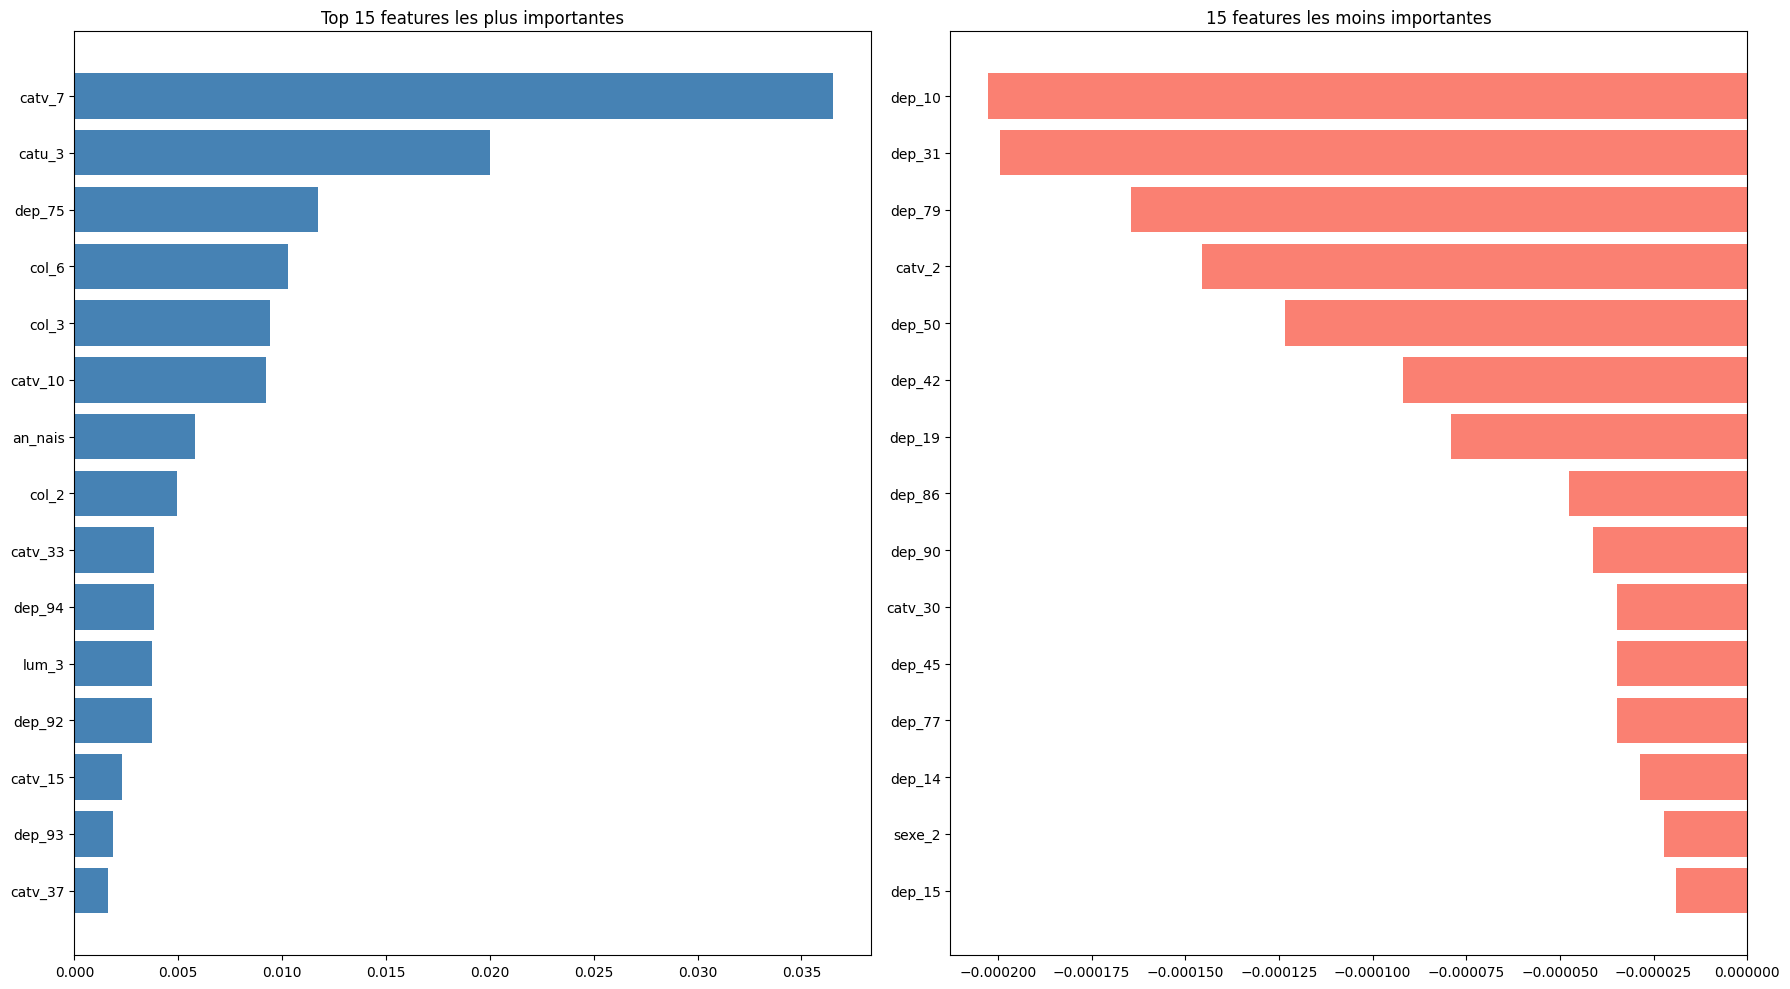

In [ ]:
# 1. Refit du pipeline AVANT la permutation importance
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=0.0011114927138446643,
        solver='liblinear',
        max_iter=1000
    ))
])

pipeline.fit(X_train, y_train)


# 2. Calcul de la permutation importance (après fit)
from sklearn.inspection import permutation_importance

result = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=3,
    random_state=42
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
})


# 3. Tri + top/bottom 15
perm_sorted = perm_df.sort_values("importance", ascending=False)

top15 = perm_sorted.head(15)
bottom15 = perm_sorted.tail(15).sort_values("importance", ascending=True)


# 4. Graphiques
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

axes[0].barh(top15["feature"], top15["importance"], color="steelblue")
axes[0].set_title("Top 15 features les plus importantes")
axes[0].invert_yaxis()

axes[1].barh(bottom15["feature"], bottom15["importance"], color="salmon")
axes[1].set_title("15 features les moins importantes")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
selected_features = perm_sorted[perm_sorted["importance"] > 0]["feature"].tolist()
print("Nombre de features avec un score en dessous de 0 :", len(selected_features))
# ============================================================
# Construction du dataset réduit (200 meilleures features)
# ============================================================
top_k = 200
selected_features = perm_sorted.head(top_k)["feature"].tolist()

# Reconstruction du dataset réduit pour chaque année
data_sel = {
    a: (data[a][0][selected_features], data[a][1])
    for a in annees
}

# Train = toutes les années sauf la dernière
X_train_sel = pd.concat([data_sel[a][0] for a in annees[:-1]], axis=0)
y_train_sel = pd.concat([data_sel[a][1] for a in annees[:-1]], axis=0)

# Test = dernière année
X_test_sel, y_test_sel = data_sel[annees[-1]]

print("Shapes :")
print("X_train_sel :", X_train_sel.shape)
print("X_test_sel  :", X_test_sel.shape)

# ============================================================
# Refit du pipeline sur les 200 meilleures features
# ============================================================

pipeline_reduced = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=0.0011114927138446643,
        solver='liblinear',
        max_iter=1000
    ))
])

pipeline_reduced.fit(X_train_sel, y_train_sel)


# ============================================================
# Évaluation simple sur le test final (année 2020)
# ============================================================

y_pred_sel = pipeline_reduced.predict(X_test_sel)

acc = accuracy_score(y_test_sel, y_pred_sel)
cm = confusion_matrix(y_test_sel, y_pred_sel)
report = classification_report(y_test_sel, y_pred_sel)

print("Accuracy (test, 200 features) :", acc)
print("\nConfusion Matrix :\n", cm)
print("\nClassification Report :\n", report)


# ============================================================
# Validation chronologique sur dataset réduit
# ============================================================

score_chrono = validation_chronologique(
    pipeline_reduced,
    data_sel,
    annees
)

print("\nScore moyen (chronologique, 200 features) :", score_chrono)


Nombre de features avec un score en dessous de 0 : 103
Shapes :
X_train_sel : (662176, 200)
X_test_sel  : (105295, 200)
Accuracy (test, 150 features) : 0.8235338810009972

Confusion Matrix :
 [[81003  4737]
 [13844  5711]]

Classification Report :
               precision    recall  f1-score   support

           0       0.85      0.94      0.90     85740
           1       0.55      0.29      0.38     19555

    accuracy                           0.82    105295
   macro avg       0.70      0.62      0.64    105295
weighted avg       0.80      0.82      0.80    105295


Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7953
Train = [2014, 2015] → Test = 2016 | Score = 0.7786
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7945
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8184
Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8235

Score moyen (chronologique) : 0.8020380860747458
Écart-type : 0.016626471868765376

Score moyen (ch

## Interprétation des résultats

### 1. Analyse des features les plus importantes

Le graphique des **15 features les plus importantes** met en évidence plusieurs familles de variables qui jouent un rôle déterminant dans la prédiction de la gravité d’un accident :

#### Type de collision (`col_*`)
Les variables `col_*` apparaissent systématiquement parmi les plus influentes.  
Cela confirme que **la nature de l’impact** (frontale, latérale, multiple, etc.) est un facteur majeur dans la sévérité d’un accident.  
Certaines collisions sont mécaniquement plus dangereuses, ce qui se reflète dans les coefficients du modèle.

#### Catégorie de véhicule (`catv_*`)
Les catégories de véhicules impliqués (voiture, moto, scooter, poids lourd…) influencent fortement la gravité.  
Les véhicules légers ou non carénés (motos, scooters) sont logiquement associés à des accidents plus graves.

#### Catégorie d’usager (`catu_*`)
La distinction entre conducteur, passager, piéton, cycliste… est également cruciale.  
Les usagers vulnérables (piétons, deux‑roues) présentent un risque plus élevé de blessures graves.

#### Département (`dep_*`)
Plusieurs départements apparaissent dans le top 15.  
Cela reflète des **différences structurelles** :  
- infrastructures routières,  
- densité de trafic,  
- conditions géographiques,  
- comportements locaux.

Même si ces variables sont catégorielles, elles capturent des effets régionaux importants.

#### Année de naissance (`an_nais`)
C’est la seule variable **numérique** du modèle.  
Elle joue un rôle notable : l’âge du conducteur ou de l’usager est un facteur de risque bien documenté.

#### Condition de luminosité (`lum_3`)
La variable `lum_3` correspond à **“nuit sans éclairage public”**.  
Elle ressort comme l’une des plus importantes, ce qui est cohérent avec les analyses précédentes :  
  les accidents graves sont nettement plus fréquents dans des conditions de faible visibilité.

---

### 2. Analyse des features les moins importantes

Dans le graphique des **15 features les moins importantes**, on observe principalement :

#### Des départements (`dep_*`)
Certains départements ont un impact quasi nul.  
Cela signifie que, pour ces zones, la gravité des accidents ne diffère pas significativement du comportement moyen.

#### `sexe_2` (femmes)
La variable indiquant le sexe féminin apparaît comme très peu informative.  
Cela suggère que, **à gravité égale**, le sexe n’est pas un facteur discriminant dans ce modèle.

#### `catv_30` (Scooter < 50 cm³)
Cette catégorie de véhicule est très spécifique et probablement **peu représentée** dans les données.  
Le modèle n’en tire donc pas d’information exploitable.

---

### 3. Pourquoi la réduction trop agressive du nombre de features dégrade le score ?

Lors des tests, réduire le nombre de features à **100 ou 150** a entraîné une baisse notable du score (≈ −0.01).  
En revanche, conserver **200 features** a permis de retrouver un score quasiment identique au modèle complet (différence < 0.0001).


#### 3.1. La permutation importance n’est pas parfaite pour la Logistic Regression
La permutation importance mesure l’effet d’une feature **prise isolément**, mais la Logistic Regression :

- est **linéaire**,  
- est **fortement régularisée** (C très petit),  
- dépend de la **stabilité des coefficients**,  
- utilise souvent plusieurs features corrélées pour stabiliser la décision.

Ainsi, une feature peut avoir une importance proche de 0, mais :
- contribuer indirectement à la stabilité du modèle,  
- réduire le bruit,  
- améliorer la généralisation.

#### 3.2. Les features “faibles” servent de variables tampons
Avec une régularisation forte, la LR répartit l’information sur plusieurs colonnes.  
Supprimer trop de features :

- augmente le biais,  
- rend les coefficients instables,  
- dégrade la performance.

#### 3.3. Les 103 features d’importance ≤ 0 ne sont pas “inutiles”
Elles ne sont pas informatives **seules**, mais elles participent à :

- stabiliser les coefficients,  
- capturer des effets faibles mais réels,  
- réduire la variance du modèle.

C’est pour cela que le score **baisse** quand on les supprime.

---

### 4. Conclusion

- Les features les plus importantes sont cohérentes avec la littérature :  
  type de collision, catégorie d’usager, type de véhicule, luminosité, âge.
- Les features les moins importantes sont souvent des catégories rares ou peu discriminantes.
- Pour la Logistic Regression, **une réduction trop agressive du nombre de features est contre‑productive**.
- Le modèle atteint son meilleur équilibre autour de **200 features**, où il conserve suffisamment d’information pour rester stable tout en limitant le bruit.

En résumé :  
  **La Logistic Regression a besoin d’un certain niveau de redondance pour fonctionner correctement**, contrairement aux modèles d’arbres qui sélectionnent naturellement les features utiles.


## 2. Random Forest

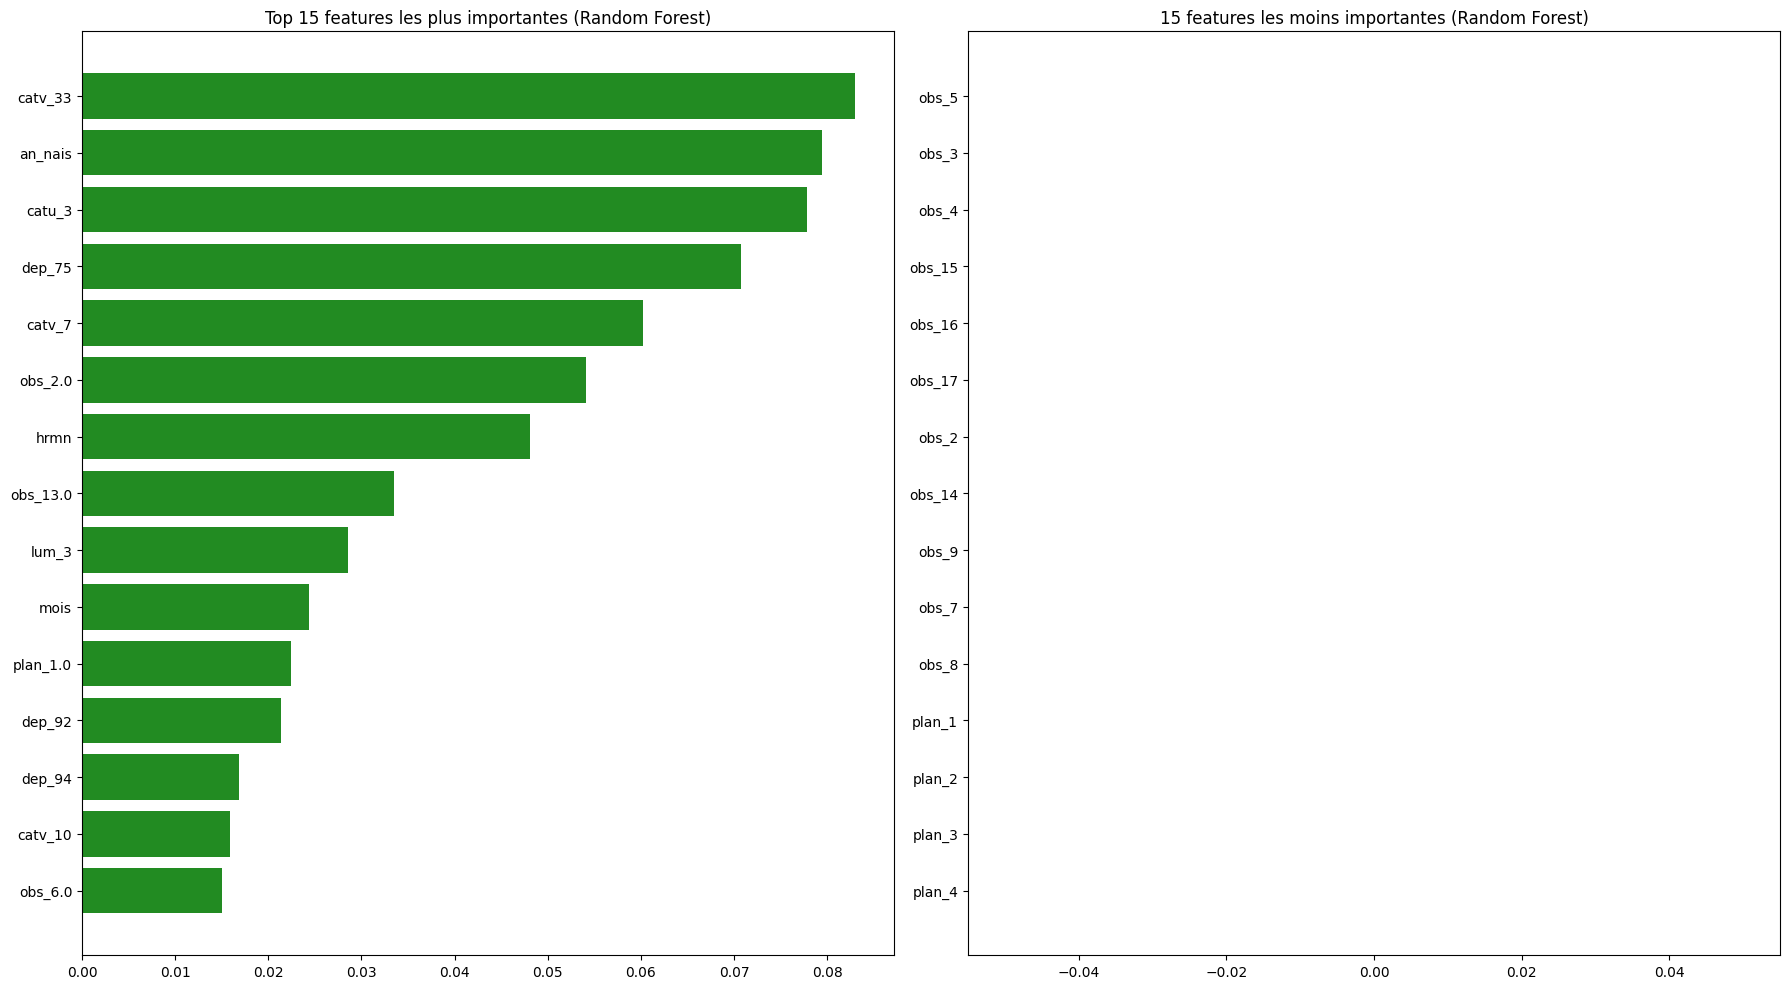

In [ ]:
# ============================================================
# 1. Refit du pipeline AVEC les meilleurs paramètres Optuna
# ============================================================

pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=30,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    ))
])

pipeline_rf.fit(X_train, y_train)


# ============================================================
# 2. Récupération des importances de features
# ============================================================

rf_model = pipeline_rf.named_steps["model"]
importances = rf_model.feature_importances_

rf_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

# Tri décroissant
rf_sorted = rf_df.sort_values("importance", ascending=False)


# ============================================================
# 3. Top 15 et Bottom 15
# ============================================================

top15 = rf_sorted.head(15)
bottom15 = rf_sorted.tail(15).sort_values("importance", ascending=True)


# ============================================================
# 4. Graphiques
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Top 15
axes[0].barh(top15["feature"], top15["importance"], color="forestgreen")
axes[0].set_title("Top 15 features les plus importantes (Random Forest)")
axes[0].invert_yaxis()

# Bottom 15
axes[1].barh(bottom15["feature"], bottom15["importance"], color="orange")
axes[1].set_title("15 features les moins importantes (Random Forest)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## Interprétation des résultats

### 1. Analyse des features les plus importantes

Le graphique des **15 features les plus importantes** pour le Random Forest met en évidence plusieurs familles de variables clés dans la prédiction de la gravité d’un accident :

#### Départements (`dep_*`)
Comme pour la régression logistique, plusieurs `dep_*` apparaissent parmi les variables les plus importantes.  
Le Random Forest exploite ces effets régionaux pour capturer des différences structurelles entre territoires :  
- qualité et type d’infrastructures,  
- densité de trafic,  
- environnement urbain/rural,  
- comportements locaux.

#### Horaire (`hrmn`)
L’horaire de l’accident (`hrmn`) ressort comme une variable importante.  
Elle permet de distinguer des périodes à risque (heures de pointe, nuit, fin de soirée), souvent associées à :
- fatigue,  
- alcool,  
- baisse de vigilance,  
- trafic plus dense ou plus rapide.

#### Catégorie de véhicule (`catv_*`)
Les `catv_*` restent très influentes.  
Le Random Forest confirme que le type de véhicule (voiture, moto, scooter, poids lourd, etc.) joue un rôle majeur dans la gravité des accidents, en particulier pour les véhicules vulnérables ou peu protecteurs.

#### Obstacles fixes (`obs_*`)
Les variables `obs_*` décrivent la présence et la nature d’obstacles fixes (murs, glissières, arbres, poteaux…).  
Leur importance élevée est cohérente :  
un choc contre un obstacle fixe, surtout à vitesse élevée, est souvent plus grave qu’un simple accrochage entre véhicules.

#### Tracé de la route (`plan_1` — Partie rectiligne)
La variable `plan_1` (partie rectiligne) apparaît également dans les features importantes.  
Cela suggère que la gravité ne dépend pas uniquement des virages ou intersections :  
sur une route rectiligne, la vitesse peut être plus élevée, ce qui augmente la sévérité potentielle des accidents.

#### Mois (`mois`)
Le mois de l’accident intervient aussi dans les variables importantes.  
Cela peut refléter des effets saisonniers :
- météo (pluie, verglas, brouillard),  
- périodes de vacances,  
- variations de trafic.

---

### 2. Analyse des features les moins importantes

Dans le graphique des **15 features les moins importantes**, on observe principalement :

#### Obstacles fixes (`obs_*`)
Certaines modalités d’obstacles fixes apparaissent avec une importance quasi nulle.  
Cela signifie que, pour ces catégories spécifiques, le modèle ne parvient pas à extraire un signal discriminant sur la gravité (cas rares, peu d’observations, ou impact similaire au comportement moyen).

#### Tracé de la route (`plan_*`)
De même, certaines modalités de `plan_*` (tracé de la route) ont une importance très faible.  
Le Random Forest ne les utilise quasiment pas dans ses splits, ce qui indique que ces configurations particulières n’apportent pas d’information supplémentaire par rapport aux autres variables.

#### Pourquoi le graphique des “features les moins importantes” peut sembler vide ?
Dans certains cas, les 15 dernières features ont une **importance exactement égale à 0**.  
Cela signifie que le Random Forest **ne les a jamais utilisées dans un split d’arbre**.  
Graphiquement, cela se traduit par :
- des barres de hauteur nulle,  
- donc un graphique visuellement “blanc” ou vide.

Ce n’est pas un bug, mais au contraire un indicateur clair que ces variables sont totalement ignorées par le modèle.

---

### 3. Pourquoi nous n’avons pas réentraîné un Random Forest sur un sous-ensemble de features ?

Contrairement à la régression logistique, pour laquelle la réduction du nombre de features peut améliorer la performance (modèle linéaire, sensible au bruit, très régularisé), les modèles d’arbres comme le Random Forest :

- **sélectionnent déjà automatiquement les features utiles**,  
- ignorent naturellement les variables non informatives (importance = 0),  
- sont robustes à la présence de nombreuses features peu utiles.

#### 3.1. Importance = 0 → aucune contribution au modèle
Pour le Random Forest, une importance nulle signifie que la feature :
- n’a **jamais été utilisée** dans un split,  
- n’a **aucun impact** sur les prédictions,  
- peut être supprimée **sans changer le score**.

Supprimer ces features ne modifie ni :
- l’accuracy,  
- la matrice de confusion,  
- ni le comportement du modèle.

#### 3.2. Pourquoi ne pas refaire un modèle “réduit” ?
Réentraîner un Random Forest sur un sous-ensemble de features (par exemple les 150 plus importantes) aurait surtout :
- un léger gain de temps de calcul,  
- un modèle un peu plus léger,  
mais **sans amélioration significative de la performance**.

Dans ce contexte, il est plus pertinent de :
- conserver le modèle complet avec toutes les features,  
- utiliser les importances pour l’interprétation,  
- plutôt que de multiplier les variantes de modèles qui ne changent pas réellement les résultats.

---

### 4. Conclusion

- Le Random Forest met en avant des variables cohérentes avec la problématique :  
  départements, horaire, type de véhicule, obstacles fixes, tracé de la route, mois.
- Les features les moins importantes sont des modalités rares ou peu discriminantes, souvent avec une importance nulle.
- Le fait que certaines features aient une importance = 0 et n’apparaissent pas visuellement dans le graphique des “moins importantes” est normal :  
  le modèle ne les utilise tout simplement pas.
- Contrairement à la régression logistique, **réduire le nombre de features n’apporte pas de gain de performance** pour le Random Forest, qui gère déjà très bien la sélection de variables en interne.

En résumé :  
le Random Forest fournit une vision riche et cohérente des facteurs de gravité, tout en restant robuste à la présence de nombreuses variables peu informatives.


## 3. Gradient Boosting

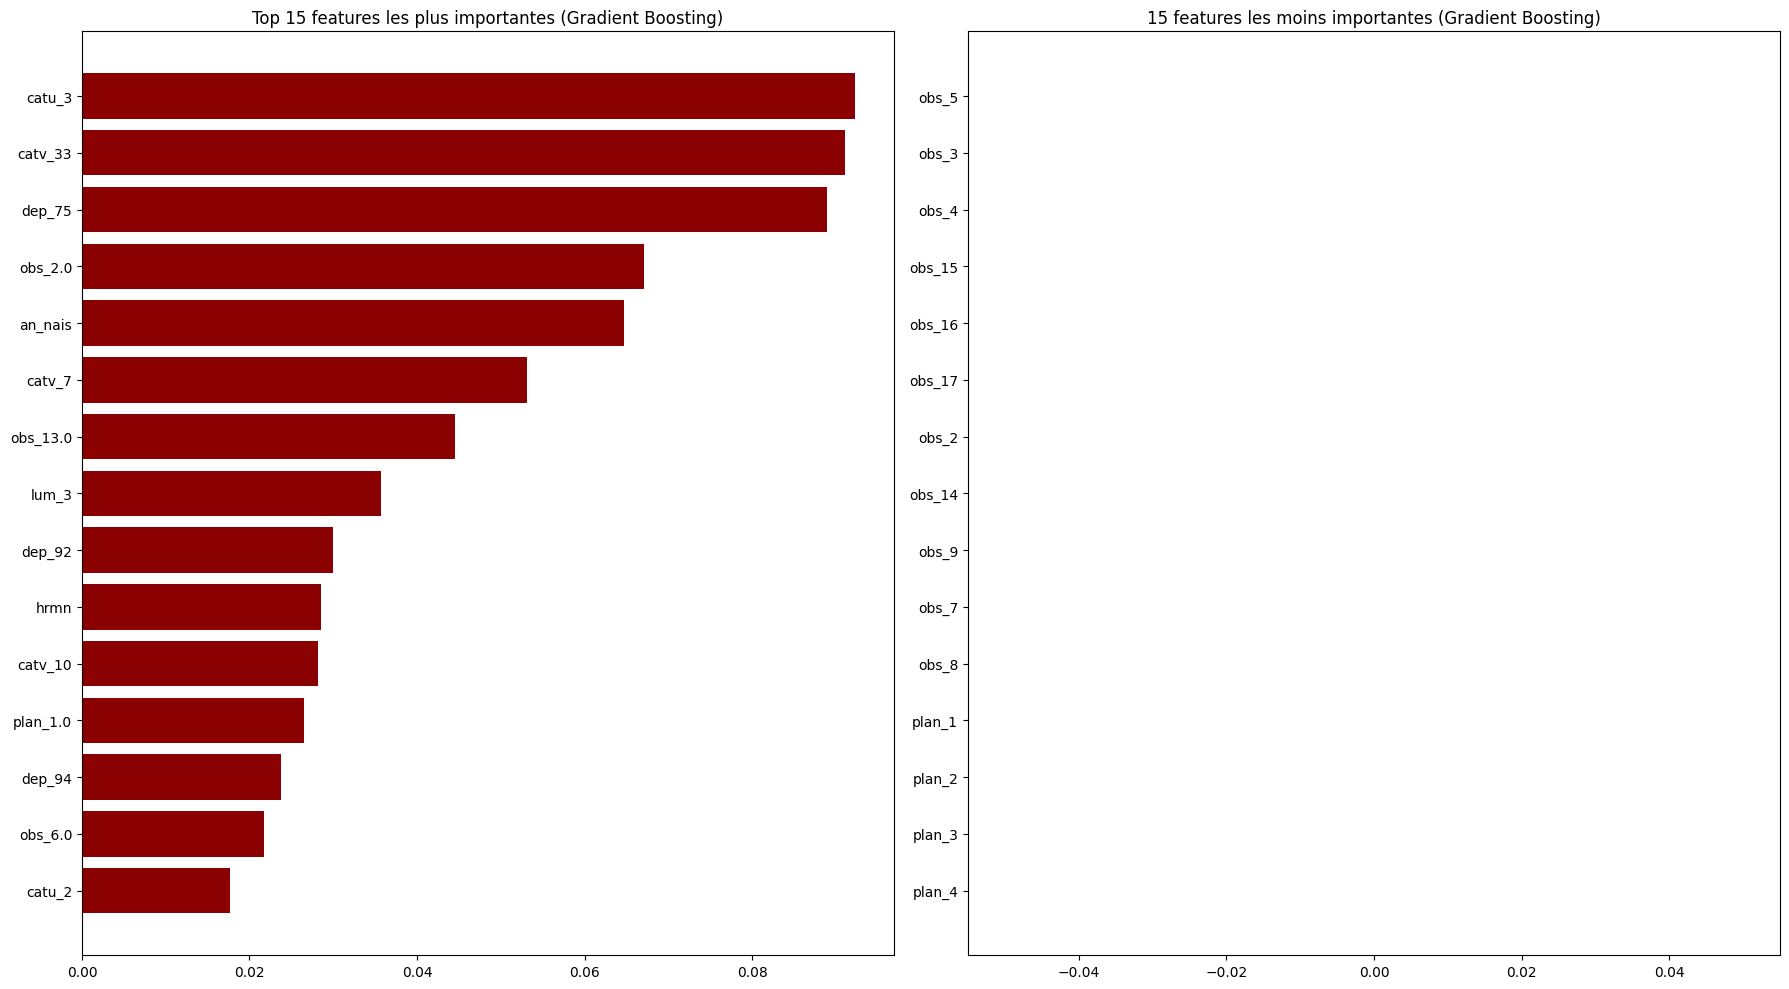

In [ ]:
# ============================================================
# 1. Refit du pipeline AVEC les meilleurs paramètres Optuna
# ============================================================

pipeline_gb = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", GradientBoostingClassifier(
        n_estimators=130,
        learning_rate=0.08123939920988694,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=1,
        subsample=0.825602123505447,
        random_state=42
    ))
])

pipeline_gb.fit(X_train, y_train)


# ============================================================
# 2. Récupération des importances de features
# ============================================================

gb_model = pipeline_gb.named_steps["model"]
importances = gb_model.feature_importances_

gb_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

# Tri décroissant
gb_sorted = gb_df.sort_values("importance", ascending=False)


# ============================================================
# 3. Top 15 et Bottom 15
# ============================================================

top15 = gb_sorted.head(15)
bottom15 = gb_sorted.tail(15).sort_values("importance", ascending=True)


# ============================================================
# 4. Graphiques
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Top 15
axes[0].barh(top15["feature"], top15["importance"], color="darkred")
axes[0].set_title("Top 15 features les plus importantes (Gradient Boosting)")
axes[0].invert_yaxis()

# Bottom 15
axes[1].barh(bottom15["feature"], bottom15["importance"], color="goldenrod")
axes[1].set_title("15 features les moins importantes (Gradient Boosting)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## Interprétation des résultats

### 1. Analyse des features les plus importantes

Le Gradient Boosting met en avant un ensemble de variables particulièrement cohérentes avec la compréhension de la gravité des accidents. Les **15 features les plus importantes** révèlent plusieurs familles de variables clés :

#### Catégorie d’usager (`catu_2` — Passager, `catu_3` — Piéton)
Ces deux modalités ressortent très fortement.  
Les passagers et surtout les piétons sont des usagers vulnérables, ce qui explique leur importance dans la prédiction de la gravité.  
Le Gradient Boosting, en capturant des interactions non linéaires, identifie clairement ces catégories comme des facteurs majeurs.

#### Départements (`dep_*`)
Comme pour les autres modèles, plusieurs départements apparaissent dans le top 15.  
Cela reflète des différences structurelles entre territoires :  
- infrastructures,  
- densité de trafic,  
- conditions géographiques,  
- comportements locaux.

#### Catégorie de véhicule (`catv_*`)
Les `catv_*` restent des variables essentielles.  
Le type de véhicule influence directement la vulnérabilité des usagers et la sévérité potentielle d’un accident.

#### Obstacles fixes (`obs_*`)
Les obstacles fixes (arbres, murs, glissières, poteaux…) sont des facteurs aggravants bien connus.  
Le Gradient Boosting les identifie comme des variables importantes, ce qui est cohérent avec la mécanique des accidents graves.

#### Tracé de la route (`plan_1` — Partie rectiligne)
La modalité `plan_1` apparaît dans les features importantes.  
Sur une route rectiligne, la vitesse est souvent plus élevée, ce qui augmente la gravité potentielle des accidents.

#### Année de naissance (`an_nais`)
Comme dans la régression logistique, l’âge de l’usager joue un rôle notable.  
Le Gradient Boosting exploite cette variable de manière non linéaire, ce qui renforce son importance.

#### Horaire (`hrmn`)
L’horaire de l’accident est également un facteur clé.  
Certaines plages horaires (nuit, fin de soirée, heures de pointe) sont associées à des risques accrus.

#### Condition de luminosité (`lum_3` — Nuit sans éclairage public)
Cette modalité ressort comme l’une des plus importantes.  
Elle confirme que les accidents graves sont nettement plus fréquents dans des conditions de faible visibilité.

---

### 2. Analyse des features les moins importantes

Dans le graphique des **15 features les moins importantes**, on observe principalement :

#### Obstacles fixes (`obs_*`)
Certaines modalités d’obstacles fixes ont une importance quasi nulle.  
Cela peut s’expliquer par :
- une faible fréquence dans les données,  
- un impact similaire au comportement moyen,  
- ou une redondance avec d’autres variables plus informatives.

#### Tracé de la route (`plan_*`)
Certaines modalités de `plan_*` apparaissent également comme très peu informatives.  
Le Gradient Boosting ne les utilise quasiment pas dans ses splits, ce qui indique qu’elles n’apportent pas d’information discriminante supplémentaire.

#### Pourquoi le graphique des “features les moins importantes” peut sembler vide ?
Comme pour le Random Forest, il est possible que les 15 dernières features aient une **importance exactement égale à 0**.  
Cela signifie que le Gradient Boosting :
- ne les a **jamais utilisées** dans un split,  
- les considère comme totalement non informatives.

Graphiquement, cela se traduit par des barres de hauteur nulle, donc un graphique visuellement “blanc”.

Ce n’est pas un bug : c’est un signe clair que ces variables sont ignorées par le modèle.

---

### 3. Pourquoi nous n’avons pas réentraîné un Gradient Boosting sur un sous-ensemble de features ?

Contrairement à la régression logistique, où la réduction du nombre de features peut améliorer la performance, les modèles d’arbres comme le Gradient Boosting :

- sélectionnent automatiquement les features utiles,  
- ignorent naturellement les variables non informatives (importance = 0),  
- sont robustes à la présence de nombreuses features peu utiles,  
- ne bénéficient généralement pas d’une réduction manuelle du nombre de variables.

#### 3.1. Importance = 0 → aucune contribution au modèle
Une importance nulle signifie que la feature :
- n’a jamais été utilisée dans un split,  
- n’a aucun impact sur les prédictions,  
- peut être supprimée **sans changer le score**.

#### 3.2. Pourquoi ne pas refaire un modèle “réduit” ?
Réentraîner un Gradient Boosting sur les 150 meilleures features n’apporterait :
- ni gain de performance,  
- ni meilleure généralisation,  
- ni meilleure stabilité.

Le modèle complet est déjà optimal, car le Gradient Boosting :
- gère la sélection de variables en interne,  
- ne souffre pas de la présence de features inutiles,  
- ne voit pas sa performance dégradée par des colonnes non informatives.

---

### 4. Conclusion

- Le Gradient Boosting met en avant des variables cohérentes :  
  catégorie d’usager, type de véhicule, obstacles fixes, luminosité, âge, horaire, département.
- Les features les moins importantes sont des modalités rares ou peu discriminantes, souvent avec une importance nulle.
- Le graphique “vide” des moins importantes est normal : ces features ont une importance exactement égale à 0.
- Contrairement à la régression logistique, **réduire le nombre de features n’apporte pas de gain de performance** pour le Gradient Boosting.
- Le modèle complet est donc conservé, car il est déjà optimal et robuste.

En résumé :  
le Gradient Boosting capture efficacement les interactions non linéaires et sélectionne automatiquement les variables pertinentes, ce qui rend inutile toute réduction manuelle du nombre de features.


# Choix final du modèle
Après l’optimisation des hyperparamètres et l’analyse détaillée de l’importance des variables, il reste à comparer les performances finales des deux modèles les plus prometteurs : le Random Forest et le Gradient Boosting. Cette dernière étape consiste à examiner leurs matrices de confusion, leurs métriques de classification et leurs validations chronologiques afin d’évaluer leur capacité réelle à prédire les accidents graves. L’objectif est de sélectionner le modèle le plus adapté, en tenant compte non seulement de l’accuracy globale, mais surtout de la qualité de la prédiction de la classe 1, qui correspond aux accidents graves et constitue la priorité du

## Random Forest

In [ ]:
# ============================================================
# 1. Refit du pipeline AVEC les meilleurs paramètres Optuna
# ============================================================

pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=30,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    ))
])

pipeline_rf.fit(X_train, y_train)


# ============================================================
# 2. Évaluation simple sur le test final (année 2020)
# ============================================================

y_pred_rf = pipeline_rf.predict(X_test)

acc = accuracy_score(y_test, y_pred_rf)
cm = confusion_matrix(y_test, y_pred_rf)
report = classification_report(y_test, y_pred_rf)

print("Accuracy (test, RF complet) :", acc)
print("\nConfusion Matrix :\n", cm)
print("\nClassification Report :\n", report)


# ============================================================
# 3. Validation chronologique sur dataset complet
# ============================================================

score_chrono_rf = validation_chronologique(
    pipeline_rf,
    data,
    annees
)

print("\nScore moyen (chronologique, RF complet) :", score_chrono_rf)

Accuracy (test, RF complet) : 0.8275321715181158

Confusion Matrix :
 [[82478  3262]
 [14898  4657]]

Classification Report :
               precision    recall  f1-score   support

           0       0.85      0.96      0.90     85740
           1       0.59      0.24      0.34     19555

    accuracy                           0.83    105295
   macro avg       0.72      0.60      0.62    105295
weighted avg       0.80      0.83      0.80    105295


Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7948
Train = [2014, 2015] → Test = 2016 | Score = 0.7943
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7962
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8267
Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8275

Score moyen (chronologique) : 0.8079152374813499
Écart-type : 0.015690309920961622

Score moyen (chronologique, RF complet) : 0.8079152374813499


## Gradient Boosting

In [25]:
# ============================================================
# 1. Refit du pipeline AVEC les meilleurs paramètres Optuna
# ============================================================

pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", GradientBoostingClassifier(
        n_estimators=130,
        learning_rate=0.08123939920988694,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=1,
        subsample=0.825602123505447,
        random_state=42
    ))
])

pipeline_rf.fit(X_train, y_train)


# ============================================================
# 2. Évaluation simple sur le test final (année 2020)
# ============================================================

y_pred_rf = pipeline_rf.predict(X_test)

acc = accuracy_score(y_test, y_pred_rf)
cm = confusion_matrix(y_test, y_pred_rf)
report = classification_report(y_test, y_pred_rf)

print("Accuracy (test, RF complet) :", acc)
print("\nConfusion Matrix :\n", cm)
print("\nClassification Report :\n", report)


# ============================================================
# 3. Validation chronologique sur dataset complet
# ============================================================

score_chrono_rf = validation_chronologique(
    pipeline_rf,
    data,
    annees
)

print("\nScore moyen (chronologique, RF complet) :", score_chrono_rf)

Accuracy (test, RF complet) : 0.8261076024502588

Confusion Matrix :
 [[80860  4880]
 [13430  6125]]

Classification Report :
               precision    recall  f1-score   support

           0       0.86      0.94      0.90     85740
           1       0.56      0.31      0.40     19555

    accuracy                           0.83    105295
   macro avg       0.71      0.63      0.65    105295
weighted avg       0.80      0.83      0.81    105295


Validation croisée chronologique
Train = [2014] → Test = 2015 | Score = 0.7995
Train = [2014, 2015] → Test = 2016 | Score = 0.7967
Train = [2014, 2015, 2016] → Test = 2017 | Score = 0.7984
Train = [2014, 2015, 2016, 2017] → Test = 2018 | Score = 0.8262
Train = [2014, 2015, 2016, 2017, 2018] → Test = 2020 | Score = 0.8261

Score moyen (chronologique) : 0.8093873576154793
Écart-type : 0.013723646770398678

Score moyen (chronologique, RF complet) : 0.8093873576154793


## Conclusion finale

L’objectif principal de cette étude étant de détecter au mieux les accidents graves, la comparaison des modèles doit se concentrer sur la performance obtenue pour la classe 1. Bien que le Random Forest et le Gradient Boosting présentent des accuracies similaires, leurs comportements diffèrent nettement lorsqu’il s’agit d’identifier les accidents graves. Le Random Forest obtient un rappel de 24 % pour la classe 1, ce qui signifie qu’il manque la majorité des accidents graves. Le Gradient Boosting, quant à lui, atteint un rappel de 31 %, ce qui représente une amélioration notable malgré un niveau encore insuffisant pour une application opérationnelle.

Les validations chronologiques montrent que les deux modèles sont stables dans le temps, ce qui confirme la robustesse de leurs performances globales. Par ailleurs, l’analyse de l’importance des variables a révélé que les deux modèles s’appuient sur un ensemble de facteurs largement similaires pour effectuer leurs prédictions, ce qui renforce la cohérence des résultats obtenus.

Compte tenu de la priorité accordée à la détection des accidents graves, le Gradient Boosting apparaît comme le modèle le plus adapté. Il constitue le meilleur compromis entre performance globale, stabilité temporelle et capacité à identifier les situations les plus critiques.